Dans ce projet, nous avons choisi d’utiliser deux jeux de données afin d’évaluer la robustesse et la généralisabilité des modèles étudiés, notamment les Reinforcement Learning Trees (RLT). L’utilisation d’un seul dataset ne permettrait pas de vérifier si les performances observées sont propres à un contexte particulier ou si elles se maintiennent dans des situations variées. Nous avons ainsi retenu le dataset Breast Cancer Wisconsin (Diagnostic), qui correspond à un problème de classification médicale avec 30 variables numériques, et le dataset Wine Quality, qui relève d’un problème de régression dans le domaine agroalimentaire avec une structure de données plus simple et un nombre de variables réduit. Ces deux datasets se complètent parfaitement : ils diffèrent par leur nature (classification vs régression), leur domaine d’application (santé vs industrie), leur dimensionnalité et leur taille. Ce contraste permet d’examiner le comportement de RLT et des modèles comparatifs dans des environnements hétérogènes, renforçant ainsi la pertinence et la portée des conclusions obtenues.

Dans ce notebook, on va étudier le dataset "Breast Cancer":

# Phase 1 : Business Understanding

### Business Objectif 1 : Réduire la charge de travail et le risque d’erreurs humaines en analyse médicale

L’analyse des biopsies mammaires représente une tâche lourde et exigeante pour les professionnels de santé. Elle demande du temps, de la précision et peut parfois conduire à des variations dans les évaluations d’un expert à l’autre. En mettant en place un modèle automatisé capable de fournir une première estimation du diagnostic, il devient possible d’alléger ce travail, d’apporter un soutien fiable aux médecins et de limiter les risques d’erreurs. L’objectif est donc de rendre le diagnostic plus rapide, plus cohérent et moins dépendant exclusivement de l’œil humain.

### Business Objectif 2 : Optimiser les ressources médicales en priorisant les cas à risque

Dans un contexte hospitalier où les ressources sont souvent limitées, il est crucial de pouvoir identifier rapidement les patientes qui nécessitent une attention immédiate. Un modèle prédictif capable d’estimer la probabilité qu’une tumeur soit maligne permettrait de mettre en place un tri efficace des dossiers, en faisant passer en priorité les cas les plus sensibles. Cela aiderait les équipes médicales à mieux organiser leur travail, à réduire les délais pour les situations urgentes et à concentrer leur temps sur les patientes qui en ont le plus besoin.

### Data Science Objective 1 :

Développer un modèle de classification capable de prédire automatiquement si une tumeur est bénigne ou maligne, afin d’apporter un soutien fiable et rapide au diagnostic médical.

### Data Science Objective 2 :

Identifier les variables les plus influentes pour comprendre ce qui distingue un cas à risque élevé et permettre une meilleure priorisation des patientes.

# Phase 2 : Data Understanding

In [45]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

In [46]:
bc = pd.read_csv("BreastCanDT.csv")

In [47]:
bc.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [48]:
print(" Info  : ")
bc.info()


 Info  : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se    

In [49]:
# taille du dataset
bc.shape

(569, 33)

In [50]:
bc.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [51]:
# Vérifier valeurs manquantes
missing = bc.isnull().sum()
print("Colonnes avec valeurs manquantes :")
print(missing)

Colonnes avec valeurs manquantes :
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
frac

In [52]:
#suppression de la colonne unamed :32 vide 
bc = bc.drop("Unnamed: 32", axis=1)


In [53]:
bc.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## distribution de la cible (diagnosis)

In [54]:
bc['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [55]:
bc['diagnosis'].value_counts(normalize=True) * 100

diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64

In [56]:
#encoder diagnosis
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
bc['diagnosis'] = le.fit_transform(bc['diagnosis'])


In [57]:
bc['diagnosis'].unique()


array([1, 0])

In [58]:
bc['diagnosis'].value_counts()



diagnosis
0    357
1    212
Name: count, dtype: int64

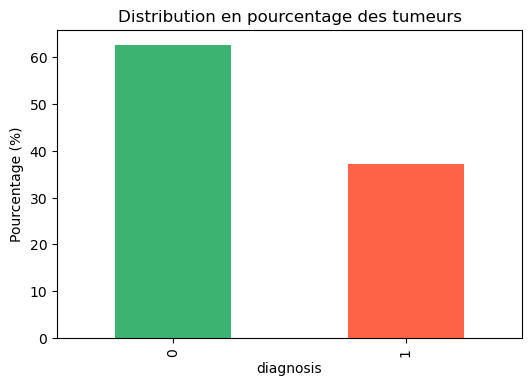

In [59]:
plt.figure(figsize=(6,4))
(bc['diagnosis'].value_counts(normalize=True) * 100).plot(kind='bar', color=['#3CB371','#FF6347'])
plt.title("Distribution en pourcentage des tumeurs")
plt.ylabel("Pourcentage (%)")
plt.show()

Interprétation: On observe un déséquilibre  entre les deux classes, avec une majorité de cas bénins (0).

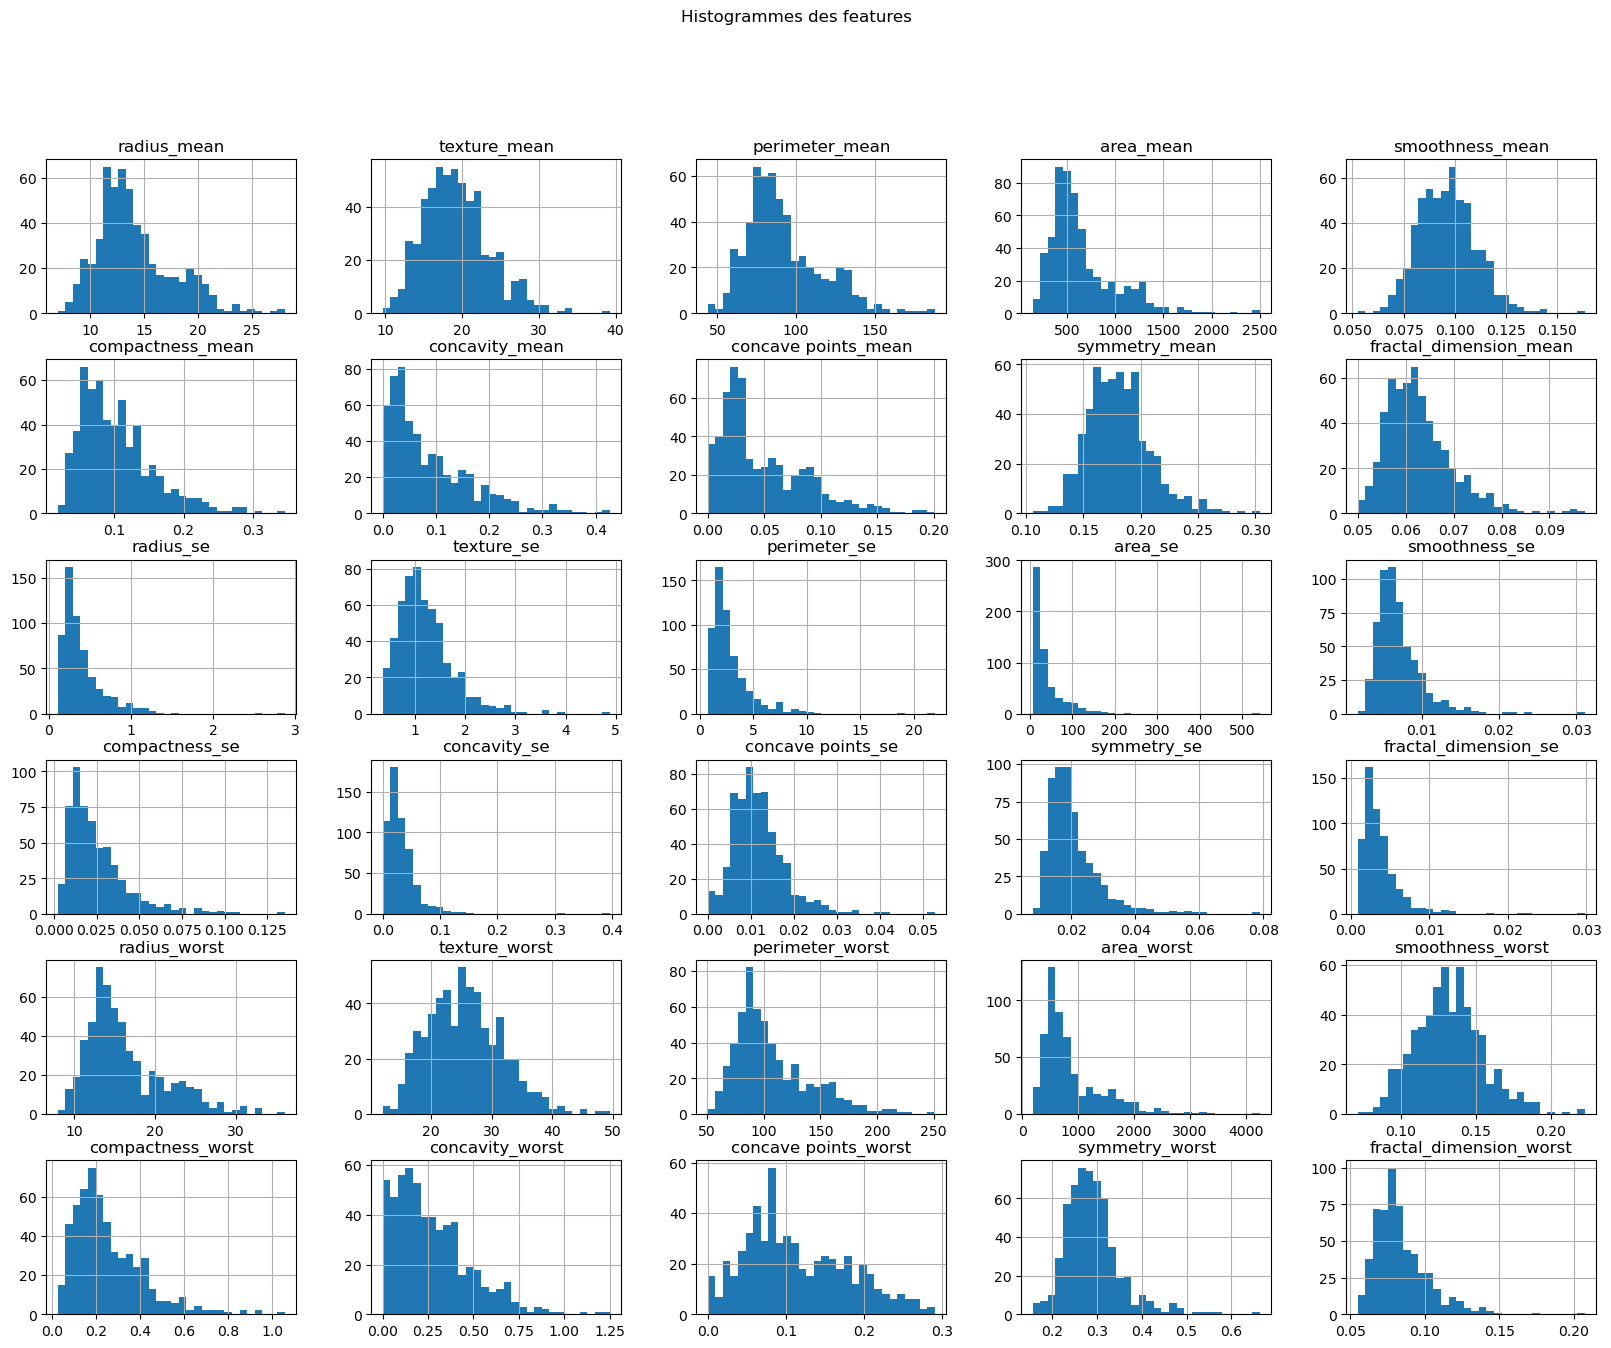

In [60]:
#Histogrammes pour voir la distribution
bc[features].hist(bins=30, figsize=(20,15))
plt.suptitle("Histogrammes des features")
plt.show()


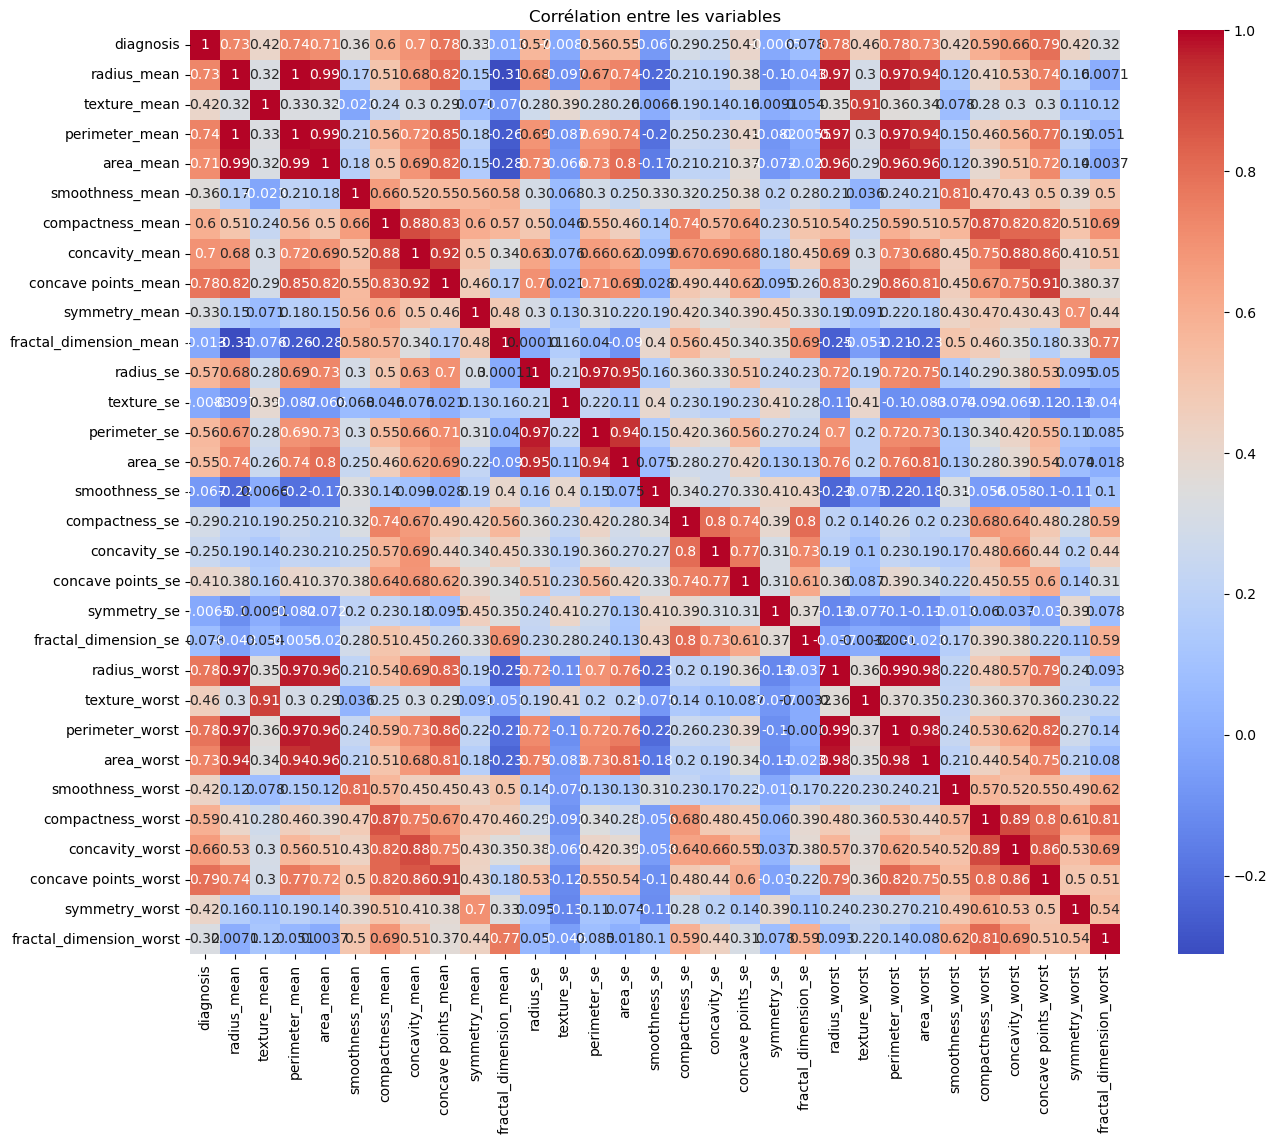

In [61]:
#Matrice de corrélation 

corr_matrix = bc.drop(columns=['id']).corr()
plt.figure(figsize=(15,12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Corrélation entre les variables")
plt.show()

In [62]:
#Table de corrélation
corr_target = corr_matrix['diagnosis'].sort_values(ascending=False)
corr_target

diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0

Interprétation:

L’analyse des corrélations entre les différentes variables et la variable cible diagnosis montre que certaines mesures des tumeurs sont fortement corrélées . Les variables les plus corrélées positivement, telles que concave points_worst (0,79), perimeter_worst (0,78), concave points_mean (0,78), radius_worst (0,78) ou encore perimeter_mean (0,74), indiquent que les tumeurs malignes ont tendance à présenter des valeurs plus élevées pour ces caractéristiques.

En revanche, certaines variables comme fractal_dimension_se, symmetry_se ou smoothness_se présentent des corrélations proches de zéro, ce qui suggère qu’elles apportent peu d’information pour distinguer les tumeurs.

In [63]:
# Standardisation des données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(bc.drop(columns=['id','diagnosis']))


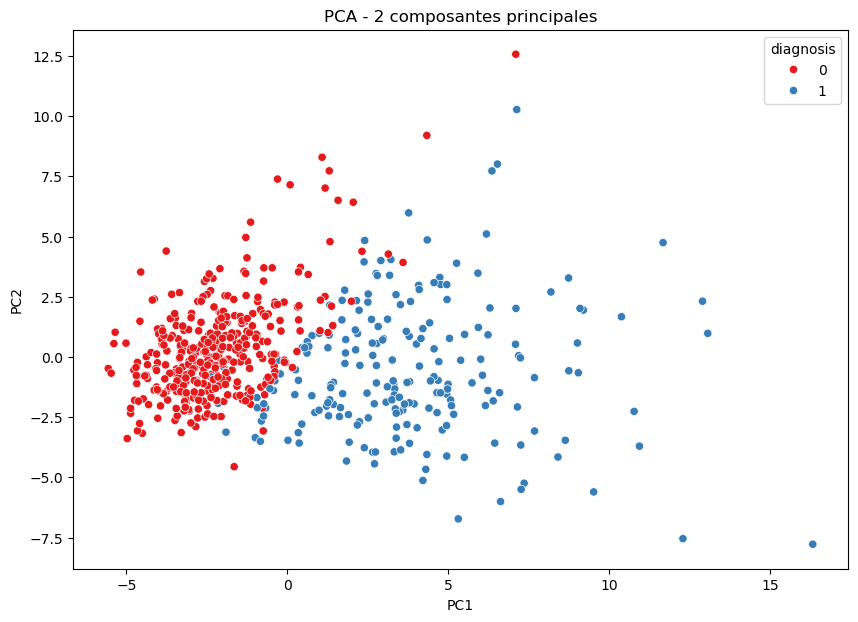

Variance expliquée par PC1 et PC2 : [0.44272026 0.18971182]
PC1 : 44.27%
PC2 : 18.97%
Variance cumulée PC1+PC2 : 63.24%


In [64]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,7))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=bc['diagnosis'], palette='Set1')
plt.title('PCA - 2 composantes principales')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

# Pourcentage de variance expliquée par chaque composante
print("Variance expliquée par PC1 et PC2 :", pca.explained_variance_ratio_)

# En pourcentage arrondi
print("PC1 : {:.2f}%".format(pca.explained_variance_ratio_[0]*100))
print("PC2 : {:.2f}%".format(pca.explained_variance_ratio_[1]*100))

# Variance cumulée (PC1 + PC2)
print("Variance cumulée PC1+PC2 : {:.2f}%".format(sum(pca.explained_variance_ratio_)*100))


Interprétation de PC1 et PC2 :
Les deux premières composantes principales (PC1 et PC2) expliquent ensemble 63,24 % de la variance totale du dataset. PC1 montre 44,27 % de la variance qui reflète la  différence entre les tumeurs bénignes et malignes, tandis que PC2 qui explique 18,97 % de la variance, apporte une information supplémentaire pour la distinction.

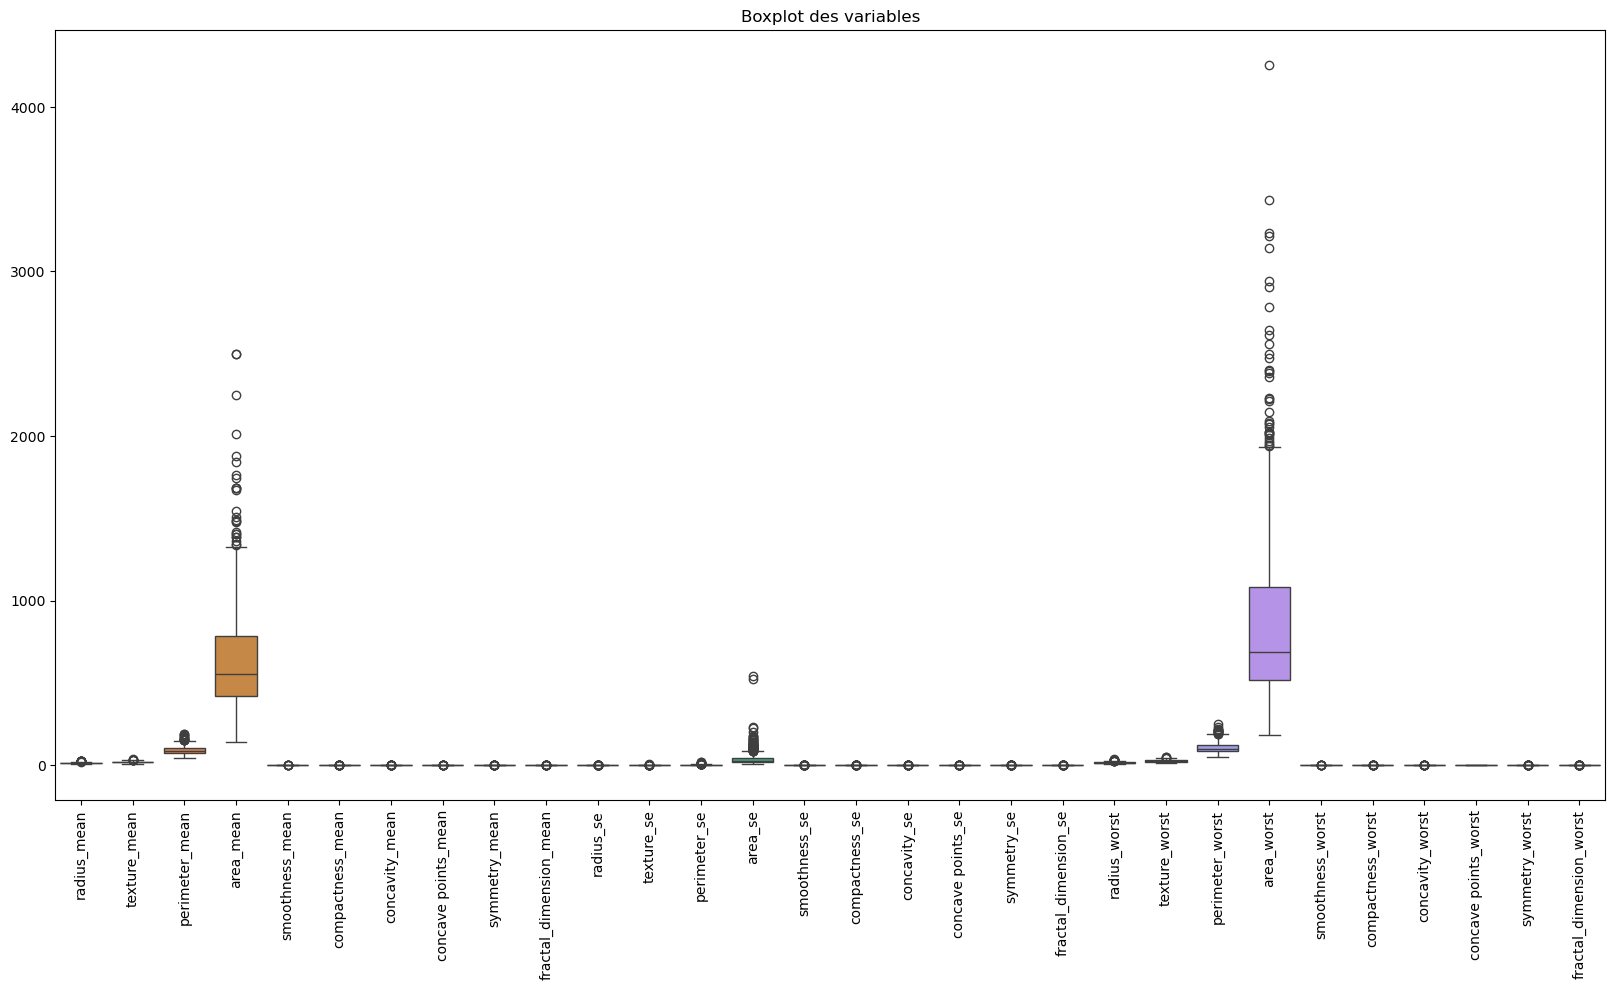

In [65]:
# Boxplot pour visualiser la distribution des variables
features = bc.columns[2:]  # ignorer id et diagnosis
plt.figure(figsize=(20,10))
sns.boxplot(data=bc[features])
plt.xticks(rotation=90)
plt.title('Boxplot des variables')
plt.show()


Interprétation : Le boxplot des variables montre que les variables  "area_mean" et "area_worst" présentent des valeurs très éloignées de la majorité des données qui sont des outliers.

# Phase 3 : Data Preparation

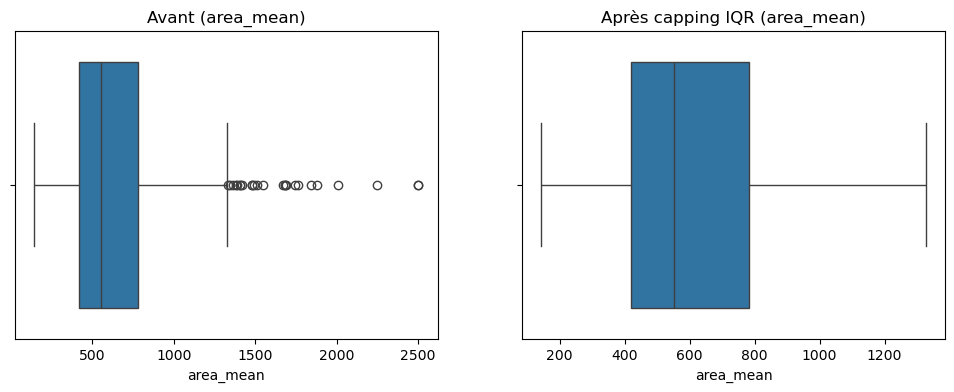

In [67]:
def cap_iqr(bc_in, cols, factor=1.5):
    bc = bc_in.copy()
    for col in cols:
        q1 = bc[col].quantile(0.25)
        q3 = bc[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - factor * iqr
        upper = q3 + factor * iqr
        bc[col] = np.where(bc[col] < lower, lower, bc[col])
        bc[col] = np.where(bc[col] > upper, upper, bc[col])
    return bc
num = bc.select_dtypes(include=[np.number])

numeric_cols = num.drop(columns=['diagnosis']).columns.tolist()
bc_capped = cap_iqr(bc, numeric_cols, factor=1.5)

# Visualiser changement sur une variable (exemple area_mean)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.boxplot(x=bc['area_mean'])
plt.title("Avant (area_mean)")
plt.subplot(1,2,2)
sns.boxplot(x=bc_capped['area_mean'])
plt.title("Après capping IQR (area_mean)")
plt.show()
